# klasifikasi Diabetes menggunakan Logistic Regression
**Dataset:** balanced_dataset.csv  
**Algoritma:** Logistic Regression  
**Evaluasi:** Accuracy, Precision, Recall, F1-Score, AUC-ROC, 5-Fold Cross-Validation

## 1. Import Library

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

print('Library berhasil di-import')

Library berhasil di-import


## 2. Load Dataset

In [27]:
df = pd.read_csv('/kaggle/input/datasets/vindiarjohandiputra/balanced-dataset-pred-diabet/balanced_dataset.csv')

# Hanya gunakan gender Male dan Female
df = df[df['gender'].isin(['Male', 'Female'])].copy()
df.reset_index(drop=True, inplace=True)

print(f'Shape data: {df.shape}')
print(f'Distribusi gender: {df["gender"].value_counts().to_dict()}')
df.head()

Shape data: (16998, 9)
Distribusi gender: {'Female': 9489, 'Male': 7509}


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Male,80.0,1,0,former,27.32,8.2,140,1
1,Female,35.0,0,0,No Info,27.32,4.5,158,0
2,Female,55.0,1,0,never,27.32,8.8,220,1
3,Male,68.0,0,0,former,28.19,3.5,100,0
4,Female,26.0,0,0,not current,21.38,5.8,155,0


## 3. Exploratory Data Analysis (EDA)

In [28]:
print('=== Info Dataset ===')
print(df.info())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16998 entries, 0 to 16997
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16998 non-null  object 
 1   age                  16998 non-null  float64
 2   hypertension         16998 non-null  int64  
 3   heart_disease        16998 non-null  int64  
 4   smoking_history      16998 non-null  object 
 5   bmi                  16998 non-null  float64
 6   HbA1c_level          16998 non-null  float64
 7   blood_glucose_level  16998 non-null  int64  
 8   diabetes             16998 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 1.2+ MB
None


In [29]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000,16998.000000
mean,50.665412,0.151488,0.088305,29.427427,6.163766,163.245264,0.500059
std,21.445955,0.358535,0.283746,7.392769,1.283926,56.973886,0.500015
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,36.000000,0.000000,0.000000,25.890000,5.700000,130.000000,0.000000
50%,54.000000,0.000000,0.000000,27.320000,6.100000,155.000000,1.000000
75%,67.000000,0.000000,0.000000,32.770000,6.600000,200.000000,1.000000
max,80.000000,1.000000,1.000000,88.720000,9.000000,300.000000,1.000000


In [30]:
print('=== Distribusi Label Target ===')
print(df['diabetes'].value_counts())
print(f'\nRasio kelas: {df["diabetes"].value_counts(normalize=True).round(3).to_dict()}')

=== Distribusi Label Target ===
diabetes
1    8500
0    8498
Name: count, dtype: int64

Rasio kelas: {1: 0.5, 0: 0.5}


In [31]:
print('=== Distribusi Fitur Kategorikal ===')
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col}:')
    print(df[col].value_counts())

=== Distribusi Fitur Kategorikal ===

gender:
gender
Female    9489
Male      7509
Name: count, dtype: int64

smoking_history:
smoking_history
never          6288
No Info        4680
former         2317
current        1710
not current    1217
ever            786
Name: count, dtype: int64


In [32]:
df.groupby('gender')['diabetes'].value_counts()

gender  diabetes
Female  0           5028
        1           4461
Male    1           4039
        0           3470
Name: count, dtype: int64

## 4. Pengecekan Missing Value

=== Jumlah Missing Value ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


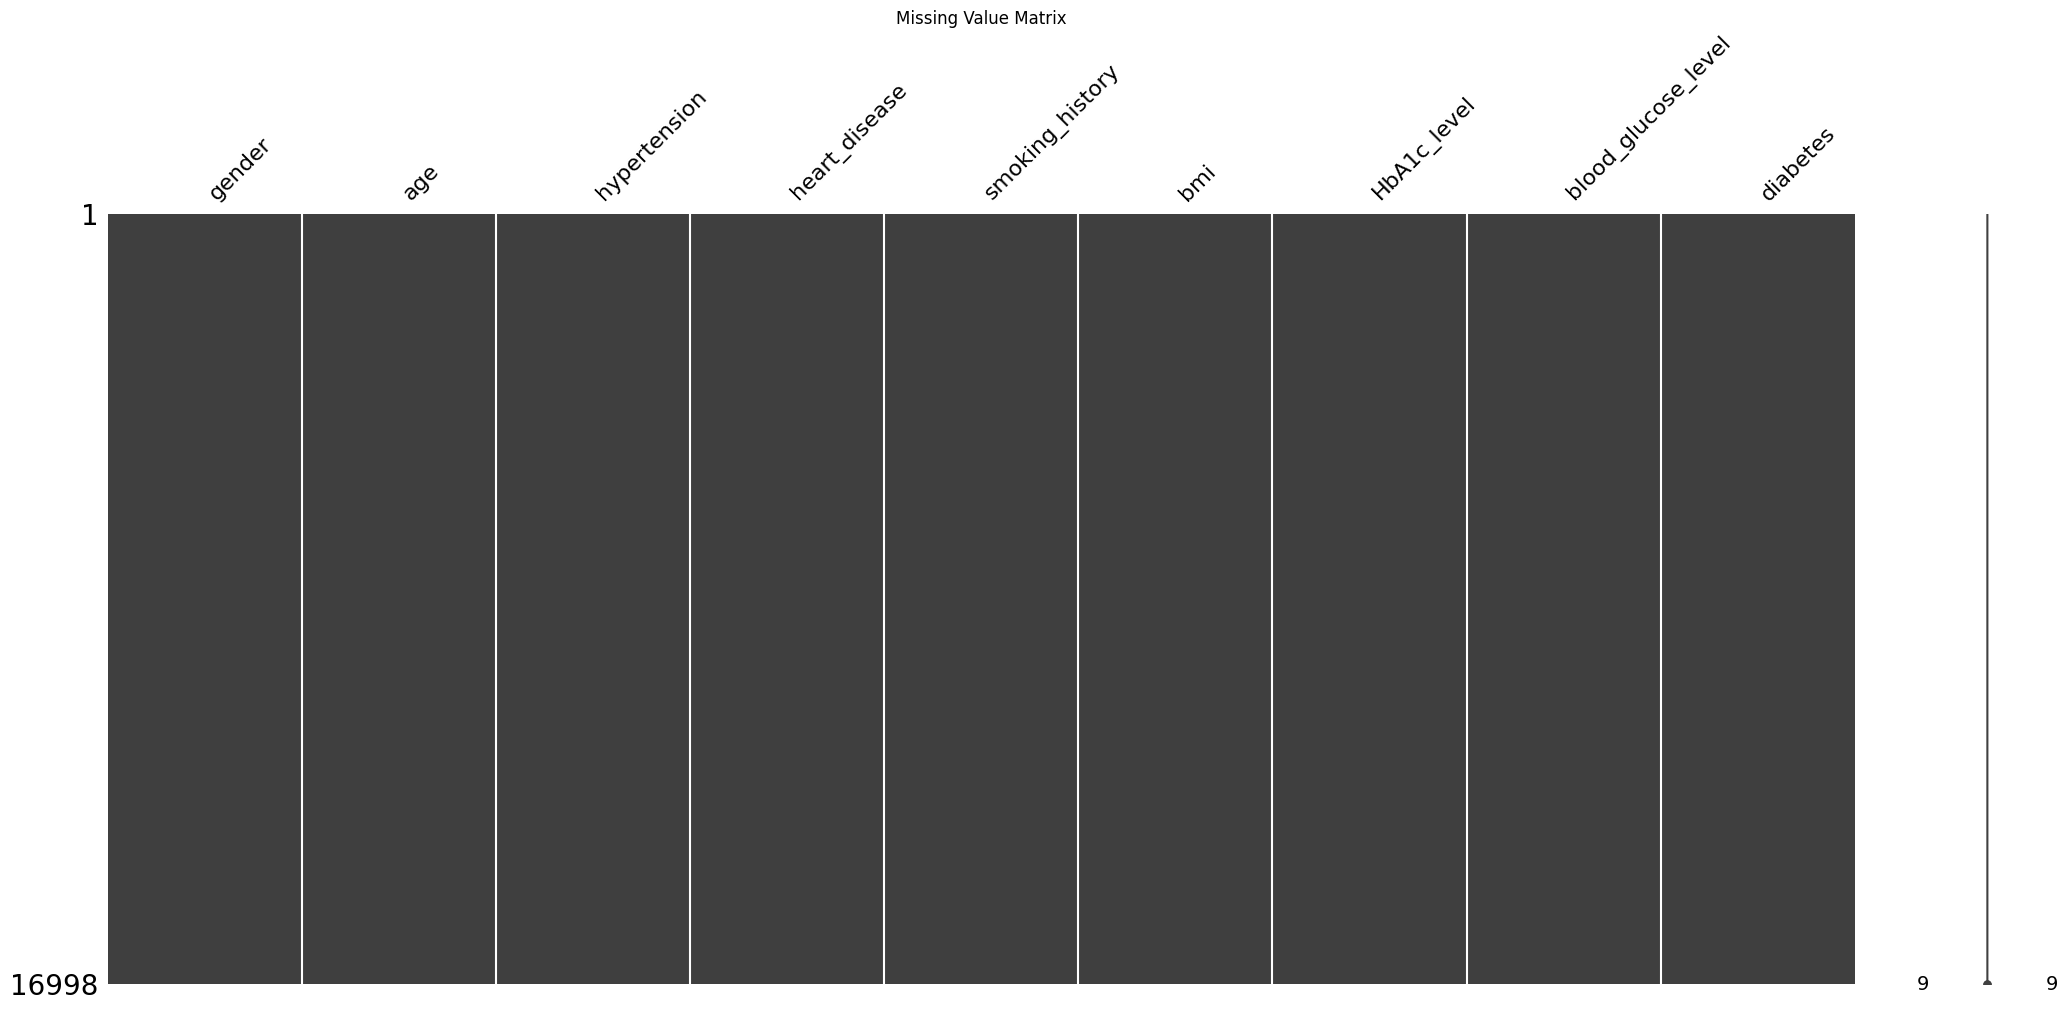

In [33]:
print('=== Jumlah Missing Value ===')
print(df.isnull().sum())
msno.matrix(df)
plt.title('Missing Value Matrix')
plt.show()

## 5. Deteksi Outlier (Sebelum Pembersihan)

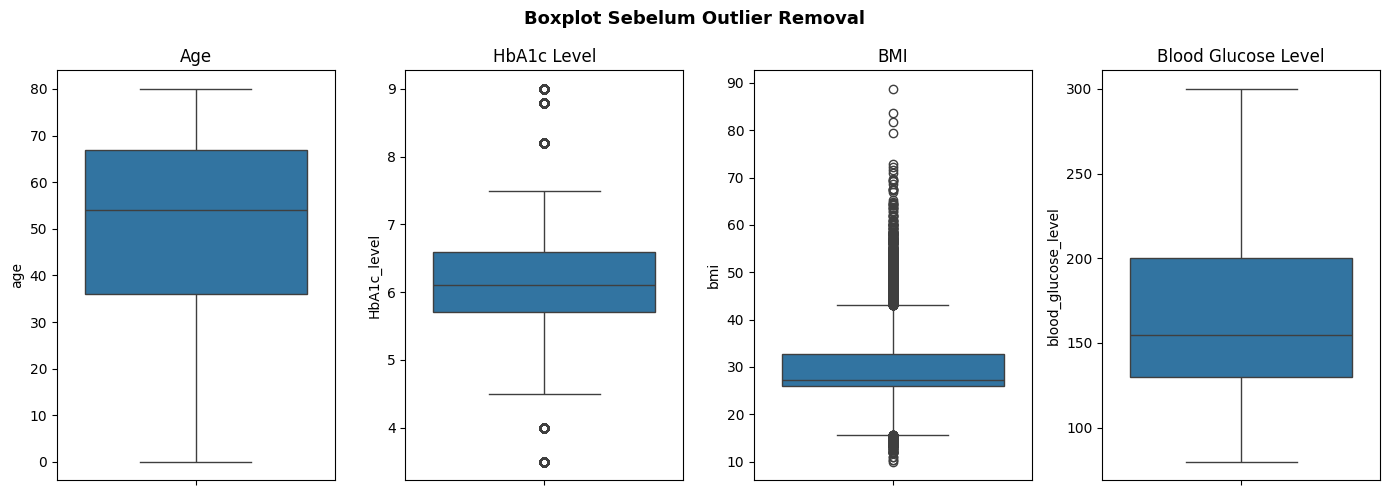

In [34]:
# FIX: axes[3] sebelumnya salah plot HbA1c lagi — sekarang sudah benar pakai blood_glucose_level
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=df['age'])
axes[0].set_title('Age')

sns.boxplot(ax=axes[1], data=df['HbA1c_level'])
axes[1].set_title('HbA1c Level')

sns.boxplot(ax=axes[2], data=df['bmi'])
axes[2].set_title('BMI')

# ✅ DIPERBAIKI: sebelumnya salah pakai df['HbA1c_level'] lagi
sns.boxplot(ax=axes[3], data=df['blood_glucose_level'])
axes[3].set_title('Blood Glucose Level')

plt.suptitle('Boxplot Sebelum Outlier Removal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Penghapusan Outlier (IQR Method)

In [35]:
num_cols = ['HbA1c_level', 'bmi', 'blood_glucose_level']

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

mask = pd.Series([True] * len(df), index=df.index)
for col in num_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    mask = mask & (df[col] >= lower) & (df[col] <= upper)

data_clean = df.loc[mask].copy()
data_clean.reset_index(drop=True, inplace=True)

print(f'Baris sebelum : {len(df)}')
print(f'Baris setelah : {len(data_clean)}')
print(f'Outlier dihapus: {len(df) - len(data_clean)} ({(len(df)-len(data_clean))/len(df)*100:.1f}%)')

Baris sebelum : 16998
Baris setelah : 12680
Outlier dihapus: 4318 (25.4%)


### Boxplot Setelah Pembersihan Outlier

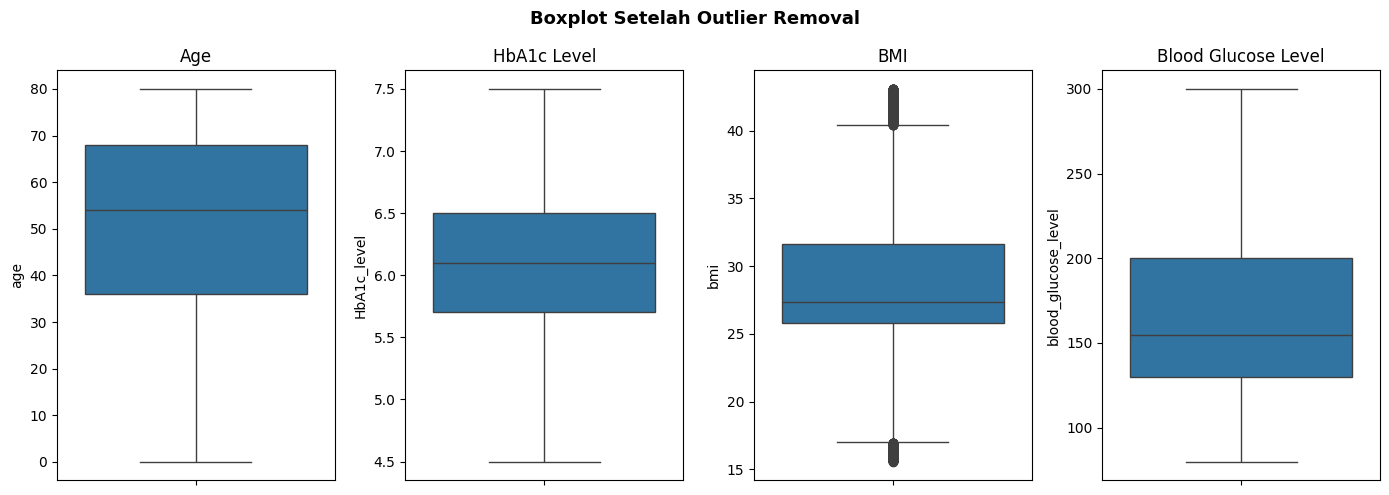

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=data_clean['age'])
axes[0].set_title('Age')

sns.boxplot(ax=axes[1], data=data_clean['HbA1c_level'])
axes[1].set_title('HbA1c Level')

sns.boxplot(ax=axes[2], data=data_clean['bmi'])
axes[2].set_title('BMI')

sns.boxplot(ax=axes[3], data=data_clean['blood_glucose_level'])
axes[3].set_title('Blood Glucose Level')

plt.suptitle('Boxplot Setelah Outlier Removal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Visualisasi Distribusi Data

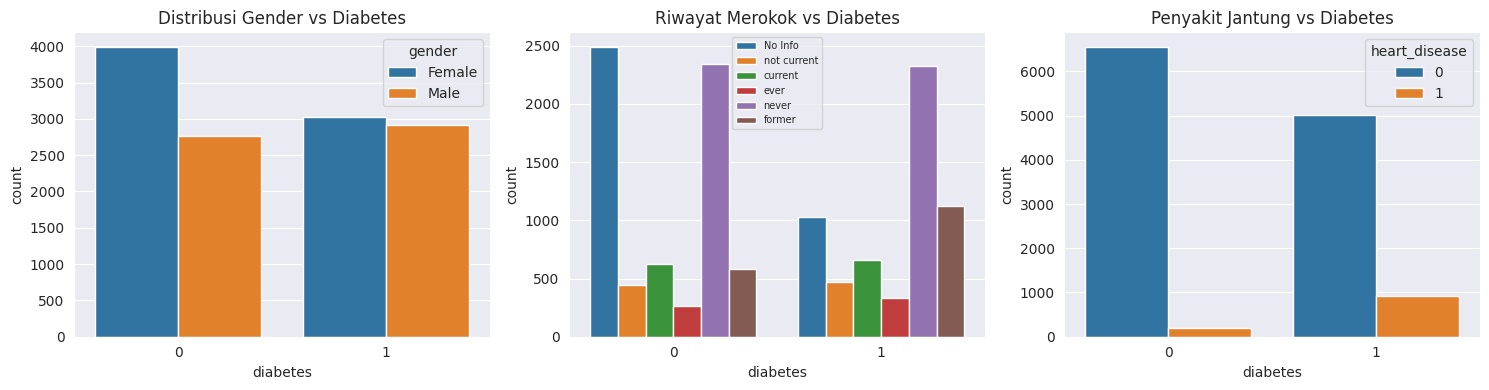

In [37]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(ax=axes[0], x='diabetes', data=data_clean, hue='gender')
axes[0].set_title('Distribusi Gender vs Diabetes')

sns.countplot(ax=axes[1], x='diabetes', data=data_clean, hue='smoking_history')
axes[1].set_title('Riwayat Merokok vs Diabetes')
axes[1].legend(fontsize=7)

sns.countplot(ax=axes[2], x='diabetes', data=data_clean, hue='heart_disease')
axes[2].set_title('Penyakit Jantung vs Diabetes')

plt.tight_layout()
plt.show()

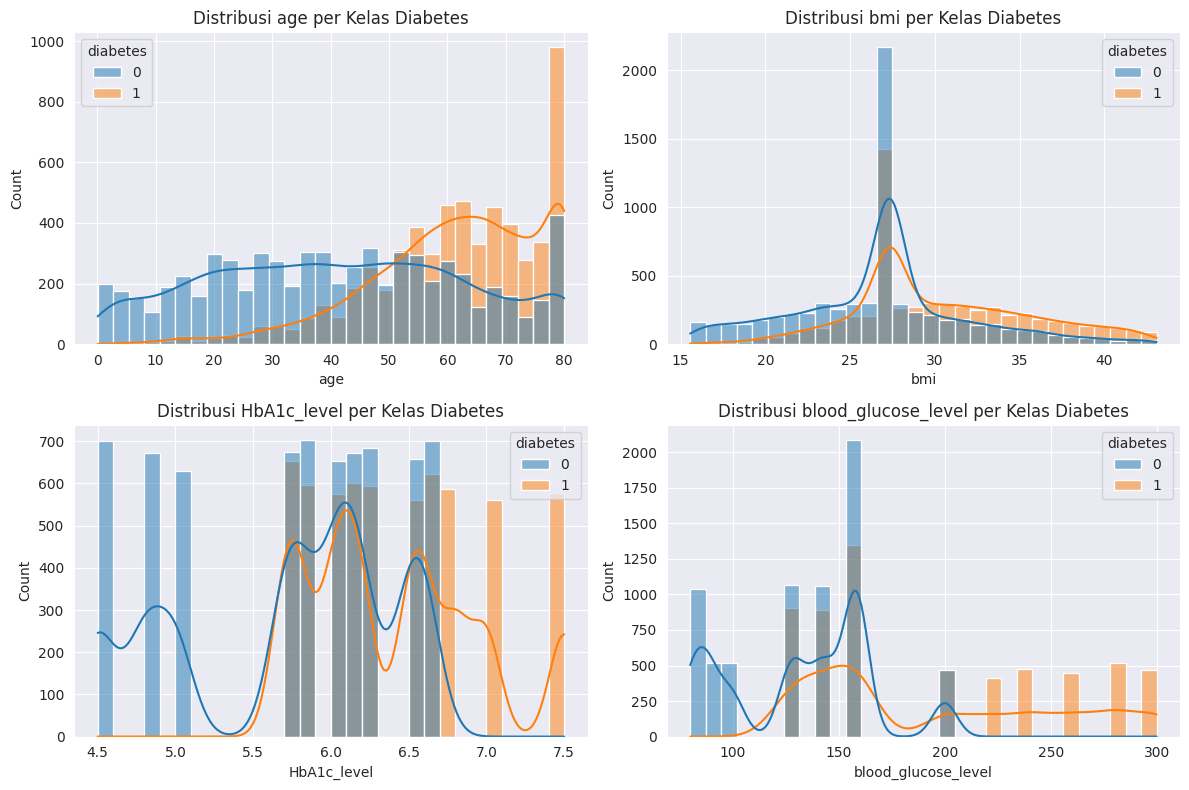

In [38]:
# Distribusi fitur numerik
num_feats = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(num_feats):
    sns.histplot(data=data_clean, x=feat, hue='diabetes',
                 kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribusi {feat} per Kelas Diabetes')

plt.tight_layout()
plt.show()

## 8. Encoding Fitur Kategorikal

> **FIX:** Sebelumnya digunakan Label Encoding untuk `gender` dan `smoking_history` yang bersifat **nominal** (tidak memiliki urutan). Ini menyebabkan model salah menginterpretasi urutan angka (misal: Male=1 > Female=0). Sekarang diganti dengan **One-Hot Encoding**.

In [39]:
df_encoded = data_clean.copy()

# One-Hot Encoding untuk kolom nominal
df_encoded = pd.get_dummies(df_encoded, columns=['gender', 'smoking_history'], drop_first=True)

print('Kolom setelah encoding:')
print(df_encoded.columns.tolist())
print(f'\nShape: {df_encoded.shape}')
df_encoded.head()

Kolom setelah encoding:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']

Shape: (12680, 13)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,35.0,0,0,27.32,4.5,158,0,False,False,False,False,False,False
1,26.0,0,0,21.38,5.8,155,0,False,False,False,False,False,True
2,3.0,0,0,18.52,6.2,85,0,True,False,False,False,False,False
3,80.0,0,0,27.32,6.0,280,1,False,False,False,False,True,False
4,57.0,0,1,40.52,6.0,126,1,True,False,False,False,True,False


## 9. Heatmap Korelasi

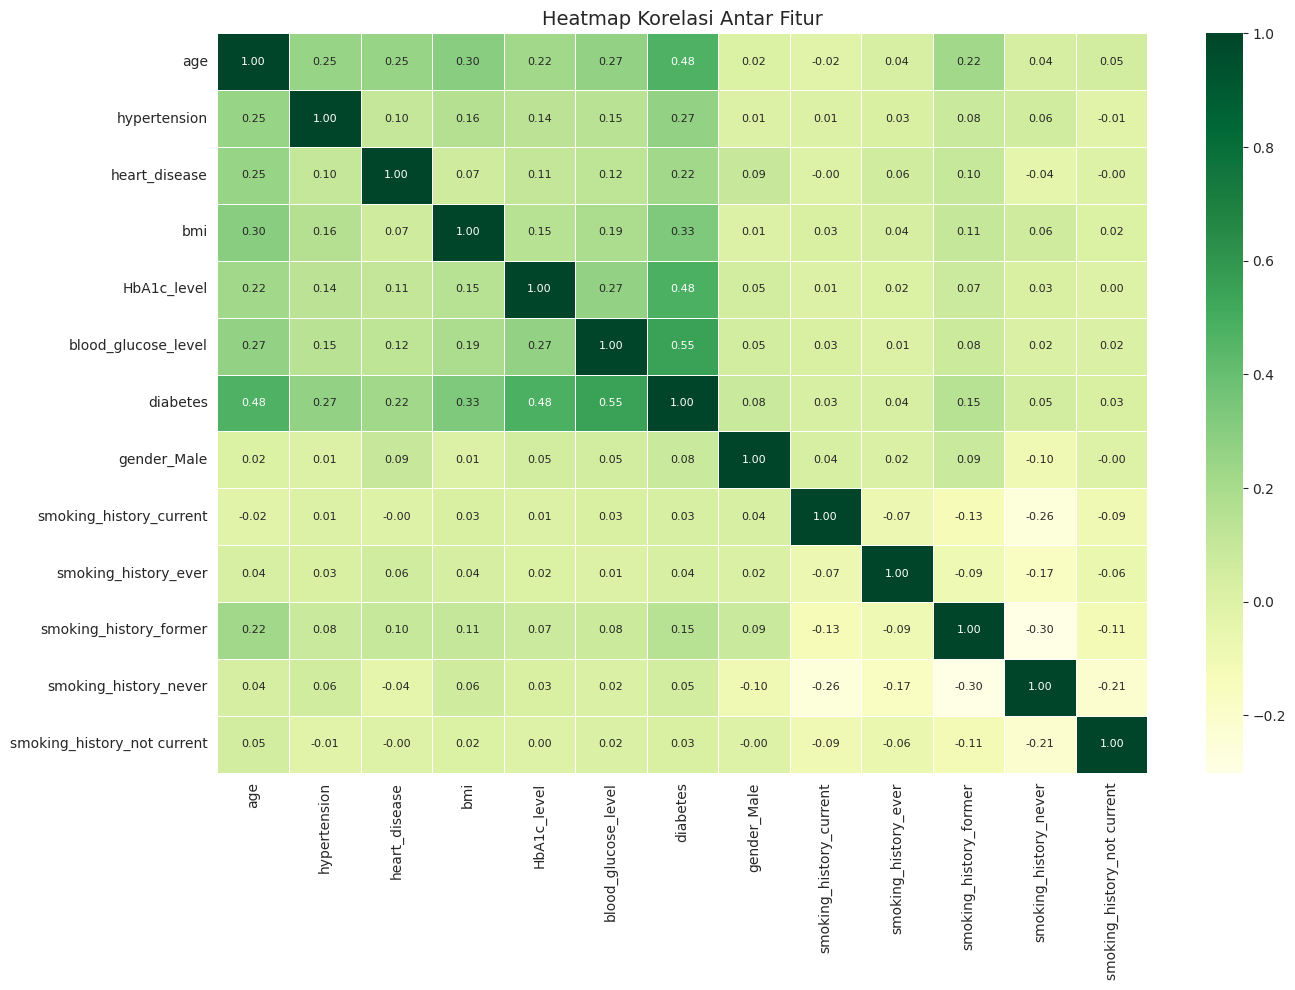

In [40]:
plt.figure(figsize=(14, 10))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Persiapan Fitur dan Target

In [41]:
# FIX: Gunakan df_encoded (sudah bersih + di-encode), bukan df asli
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nFitur yang digunakan: {X.columns.tolist()}')

Shape X: (12680, 12)
Shape y: (12680,)

Fitur yang digunakan: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


## 11. Train-Test Split (80:20)

In [42]:
# FIX: Satu split yang konsisten (80:20) menggantikan 3 split dengan rasio berbeda
# (0.20, 0.30, 0.55) yang tidak memiliki justifikasi metodologis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Data latih : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Data uji   : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')

Data latih : 10144 sampel (80%)
Data uji   : 2536 sampel (20%)


## 12. Feature Scaling

In [43]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)  # fit hanya pada data latih
X_test_sc  = sc.transform(X_test)       # transform saja pada data uji
print('Scaling selesai.')

Scaling selesai.


## 13. Pelatihan Model — Logistic Regression

In [44]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)
print('Model berhasil dilatih.')

Model berhasil dilatih.


## 14. klasifikasi dan Evaluasi

In [45]:
y_pred      = log_reg.predict(X_test_sc)
y_pred_prob = log_reg.predict_proba(X_test_sc)[:, 1]  # probabilitas kelas positif

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Accuracy: 0.8458 (84.58%)


### Confusion Matrix

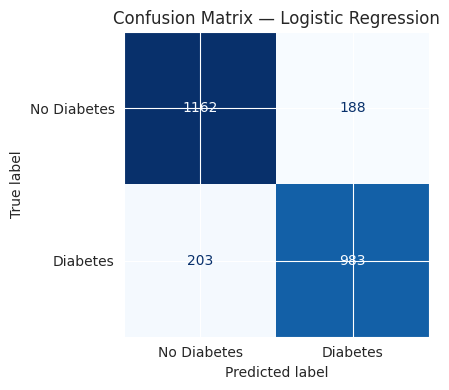

True Negative  (TN): 1162
False Positive (FP): 188
False Negative (FN): 203
True Positive  (TP): 983


In [46]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive  (TP): {tp}')

### Classification Report

In [47]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.85      0.86      0.86      1350
    Diabetes       0.84      0.83      0.83      1186

    accuracy                           0.85      2536
   macro avg       0.85      0.84      0.85      2536
weighted avg       0.85      0.85      0.85      2536



### ROC-AUC Curve

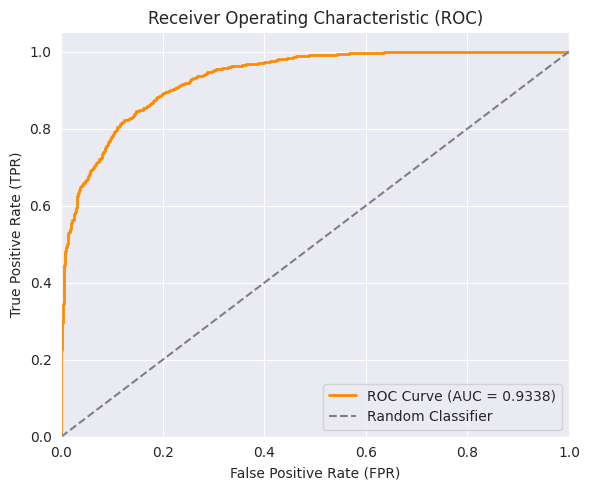

AUC-ROC Score: 0.9338


In [48]:
# FIX: gunakan y_pred_prob (probabilitas) bukan y_pred (class label)
# Sebelumnya: roc_auc_score(y_test, y_predLR) → kurang akurat
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'AUC-ROC Score: {roc_auc:.4f}')

## 15. Analisis Feature Importance (Koefisien Model)

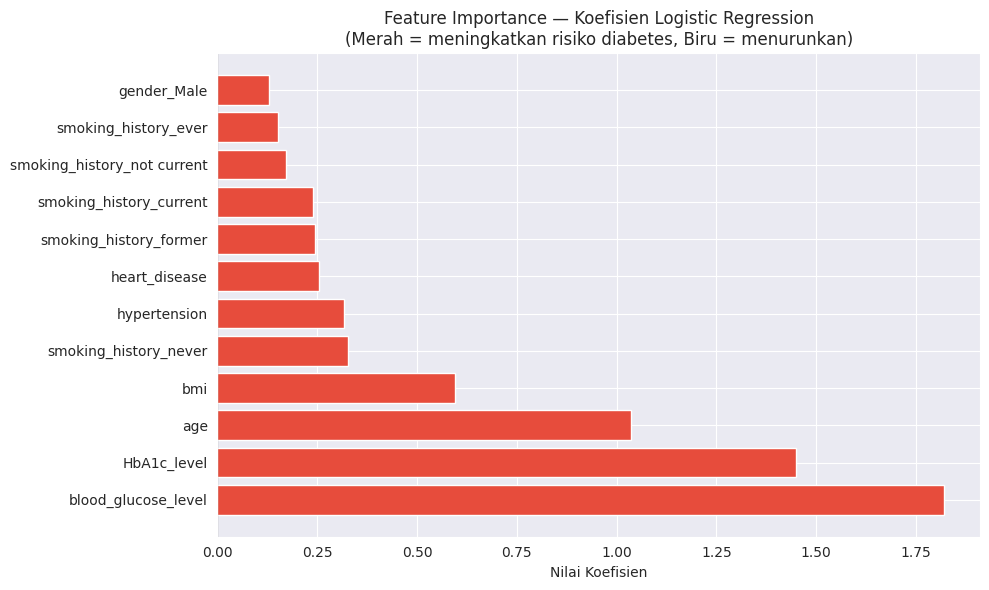

                      Fitur  Koefisien
        blood_glucose_level   1.819429
                HbA1c_level   1.449371
                        age   1.037083
                        bmi   0.594312
      smoking_history_never   0.326738
               hypertension   0.316000
              heart_disease   0.253846
     smoking_history_former   0.243239
    smoking_history_current   0.238946
smoking_history_not current   0.171376
       smoking_history_ever   0.152326
                gender_Male   0.128793


In [49]:
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_reg.coef_[0]
}).sort_values('Koefisien', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Nilai Koefisien')
plt.title('Feature Importance — Koefisien Logistic Regression\n'
          '(Merah = meningkatkan risiko diabetes, Biru = menurunkan)')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## 16. Validasi Model — 5-Fold Cross-Validation

> **FIX:** Menggantikan 3 percobaan dengan rasio split berbeda (0.20, 0.30, 0.55) yang tidak memiliki justifikasi metodologis. **Stratified K-Fold** adalah pendekatan standar untuk evaluasi model yang lebih robust.

In [50]:
from sklearn.pipeline import Pipeline

# Pipeline agar scaling tidak bocor ke fold validasi
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_dict = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(pipeline, X, y, cv=skf, scoring=metric)
    metrics_dict[metric] = scores
    print(f'{metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'(fold: {[round(s,4) for s in scores]})')

ACCURACY  : 0.8562 ± 0.0046  (fold: [np.float64(0.86), np.float64(0.8612), np.float64(0.8569), np.float64(0.8482), np.float64(0.8549)])
PRECISION : 0.8508 ± 0.0076  (fold: [np.float64(0.8559), np.float64(0.862), np.float64(0.8508), np.float64(0.842), np.float64(0.8431)])
RECALL    : 0.8399 ± 0.0054  (fold: [np.float64(0.8422), np.float64(0.8373), np.float64(0.8415), np.float64(0.8314), np.float64(0.8474)])
F1        : 0.8453 ± 0.0046  (fold: [np.float64(0.849), np.float64(0.8494), np.float64(0.8461), np.float64(0.8367), np.float64(0.8452)])
ROC_AUC   : 0.9403 ± 0.0035  (fold: [np.float64(0.9458), np.float64(0.9425), np.float64(0.9395), np.float64(0.9362), np.float64(0.9375)])


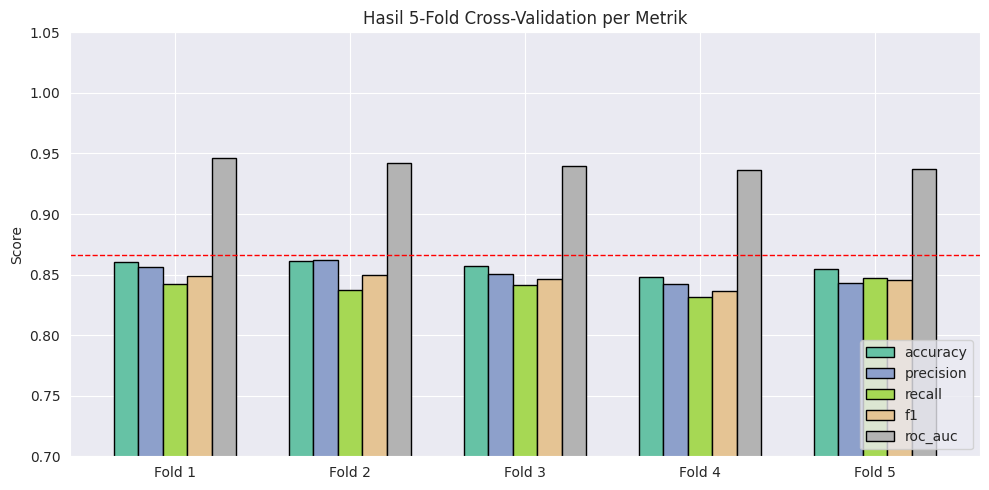

In [51]:
# Visualisasi hasil cross-validation
cv_df = pd.DataFrame(metrics_dict)

fig, ax = plt.subplots(figsize=(10, 5))
cv_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)], rotation=0)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.05)
ax.set_title('Hasil 5-Fold Cross-Validation per Metrik')
ax.legend(loc='lower right')
ax.axhline(y=cv_df.mean().mean(), color='red', linestyle='--', linewidth=1,
           label=f'Rata-rata keseluruhan')
plt.tight_layout()
plt.show()

## 17. Ringkasan Hasil Evaluasi

In [52]:
print('=' * 55)
print('       RINGKASAN EVALUASI MODEL LOGISTIC REGRESSION')
print('=' * 55)
print(f'  Dataset (setelah cleaning)  : {len(data_clean)} sampel')
print(f'  Jumlah fitur                : {X.shape[1]}')
print(f'  Split (train/test)          : 80% / 20%')
print('-' * 55)
print(f'  Accuracy  (test set)        : {accuracy_score(y_test, y_pred):.4f}')
print(f'  AUC-ROC   (test set)        : {roc_auc_score(y_test, y_pred_prob):.4f}')
print('-' * 55)
print('  5-Fold Cross-Validation:')
for metric, scores in metrics_dict.items():
    print(f'    {metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}')
print('=' * 55)

       RINGKASAN EVALUASI MODEL LOGISTIC REGRESSION
  Dataset (setelah cleaning)  : 12680 sampel
  Jumlah fitur                : 12
  Split (train/test)          : 80% / 20%
-------------------------------------------------------
  Accuracy  (test set)        : 0.8458
  AUC-ROC   (test set)        : 0.9338
-------------------------------------------------------
  5-Fold Cross-Validation:
    ACCURACY  : 0.8562 ± 0.0046
    PRECISION : 0.8508 ± 0.0076
    RECALL    : 0.8399 ± 0.0054
    F1        : 0.8453 ± 0.0046
    ROC_AUC   : 0.9403 ± 0.0035


## 18. Simpan Model

In [53]:
import joblib

# Simpan model dan scaler ke file
joblib.dump(log_reg, 'model_diabetes.pkl')
joblib.dump(sc, 'scaler_diabetes.pkl')
joblib.dump(list(X.columns), 'features_diabetes.pkl')  # simpan nama kolom

print('✅ Model    → model_diabetes.pkl')
print('✅ Scaler   → scaler_diabetes.pkl')
print('✅ Fitur    → features_diabetes.pkl')

✅ Model    → model_diabetes.pkl
✅ Scaler   → scaler_diabetes.pkl
✅ Fitur    → features_diabetes.pkl


## 19. Load Model & klasifikasi Data Baru

In [54]:
import joblib
import pandas as pd

# Load model, scaler, dan nama fitur
model    = joblib.load('model_diabetes.pkl')
scaler   = joblib.load('scaler_diabetes.pkl')
features = joblib.load('features_diabetes.pkl')

print(f'Model berhasil di-load: {type(model).__name__}')
print(f'Fitur yang dibutuhkan ({len(features)}): {features}')

Model berhasil di-load: LogisticRegression
Fitur yang dibutuhkan (12): ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [55]:
# ── Contoh klasifikasi 1 pasien baru ──────────────────────────────────

pasien_baru = {
    'age'                         : 55,
    'hypertension'                 : 1,
    'heart_disease'                : 0,
    'bmi'                          : 29.4,
    'HbA1c_level'                  : 7.2,
    'blood_glucose_level'          : 155,
    'gender_Male'                  : 1,   # 1 = laki-laki, 0 = perempuan
    'smoking_history_ever'         : 0,
    'smoking_history_former'       : 0,
    'smoking_history_never'        : 1,
    'smoking_history_not current'  : 0,
    'smoking_history_current'      : 0,
}

df_pasien    = pd.DataFrame([pasien_baru])
df_pasien    = df_pasien.reindex(columns=features, fill_value=0)
df_pasien_sc = scaler.transform(df_pasien)

klasifikasi     = model.predict(df_pasien_sc)[0]
probabilitas = model.predict_proba(df_pasien_sc)[0][1]

print('=' * 40)
print('       HASIL klasifikasi PASIEN')
print('=' * 40)
print(f'  klasifikasi       : {"⚠️  DIABETES" if klasifikasi == 1 else "✅ TIDAK DIABETES"}')
print(f'  Probabilitas   : {probabilitas:.2%}')
print(f'  Tingkat risiko : {"Tinggi" if probabilitas >= 0.7 else "Sedang" if probabilitas >= 0.4 else "Rendah"}')
print('=' * 40)


       HASIL klasifikasi PASIEN
  klasifikasi       : ⚠️  DIABETES
  Probabilitas   : 96.10%
  Tingkat risiko : Tinggi


In [56]:
# ── klasifikasi banyak pasien sekaligus (dari DataFrame / CSV) ────────
# Contoh: load dari file CSV
# df_baru = pd.read_csv('data_pasien_baru.csv')
# df_baru_encoded = pd.get_dummies(df_baru, columns=['gender', 'smoking_history'], drop_first=True)
# df_baru_encoded = df_baru_encoded.reindex(columns=features, fill_value=0)
# df_baru_sc = scaler.transform(df_baru_encoded)
# klasifikasi_semua = model.predict(df_baru_sc)
# prob_semua     = model.predict_proba(df_baru_sc)[:, 1]
# df_baru['klasifikasi']     = klasifikasi_semua
# df_baru['probabilitas'] = prob_semua
# df_baru.head()

print('Uncomment kode di atas dan sesuaikan nama file CSV untuk klasifikasi batch.')

Uncomment kode di atas dan sesuaikan nama file CSV untuk klasifikasi batch.
